# Doom training (ViZDoom)
---

## Contents

- [Background](#background)
- [Defend the center analysis](#Defend-the-center-performance-analysis)
    - [Environment + Architecture](#environment--architecture)
    - [Reward Shaping](#reward-shaping)


# Background
We trained DRL agents for two scenarios (personas) in Doom:
- Defend the center (attacker persona)
- Deadly Corridor (survivor persona)

With two different algorithms Proximal Policy Optimization (PPO) and Advantage Actor Critic (A2C). So in total, we performed 4 experiments:
- PPO on Defend the center
- A2C on Defend the center
- PPO on Deadly corridor
- A2C on Deadly corridor

These experiments were performed in the <a href="https://vizdoom.farama.org/">ViZDoom</a>. A Doom Environment for Python for purposes of training AI agents, it is maintained Farama Foundation, which also maintain the Gymnasium library (a fork of OpenAI's gym)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Defend the center performance analysis

In this section we will look at the model performance of PPO and A2C in the "Defend the Center" scenario. The scenario is created such that DoomGuy (Playable Character) is in the center of the room and enemies are spawning around. Some enemies are charging towards him as melee and others are standing still and shooting at DoomGuy. The goal of the scenario is stay alive as long as possible and eliminate as many enemies, therefore I shaped the rewards for a killer persona. The reward function for both models are the same which can be also found `envs/doom_env.py`:

```
    def step(self, action):
        ...
            kill_delta = kills - self.last_kills
            KILL_REWARD = 2.0 # double points
            reward += kill_delta * KILL_REWARD
            self.last_kills = kills

            # Death penalty
            if truncated:
                reward -= 10.0
        ...
```

This is simple reward function that rewards kills and penalizes deaths. In this section, we show the graphs of the performance of both models.

## Analysis of PPO during "Defend the Center"

Proximal Policy Optimization model was trained for 125,000 timesteps with the following parameters:
      
      HParams:
         -`policy="CnnPolicy"`
         -`learning_rate=2.5e-4`
         -`n_steps=4096`
         -`batch_size=2048`
         -`gamma=0.99`
         -`gae_lambda=0.95`
         -`clip_range=0.1`
         -`ent_coef=0.01`
         -`vf_coef=0.5`
         -`max_grad_norm=0.5`

The following graphs show total reward as metric, training loss of ppo and mean reward over timesteps during training. Analysis of the graph show no change in performance currently in total rewards. However training losses indicate that the model would eventually converge to match the optimal policy of the reward function. Moreover, mean reward is increasing over timesteps. This clearly indicates PPO is very good, it just needs a longer time to train. We also show the visual performance in the evaluation.


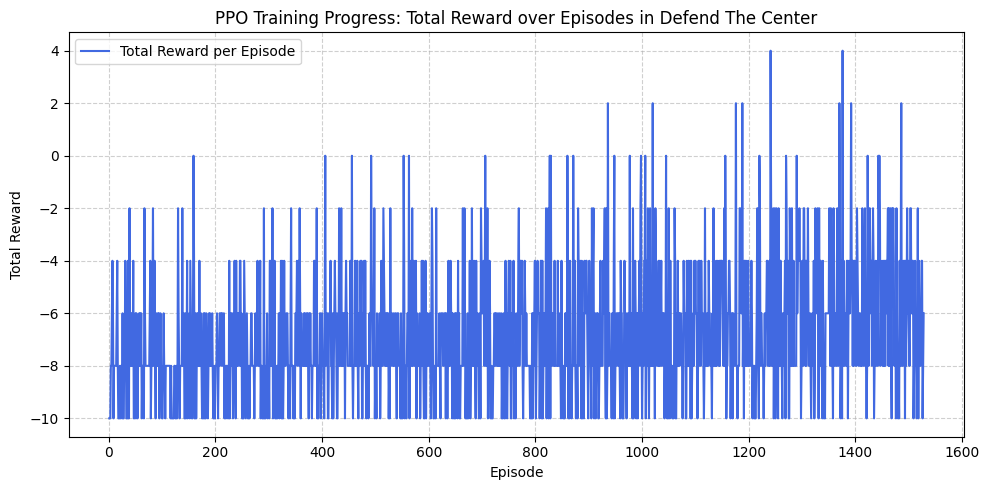

In [5]:
PPO_DEFEND_LOG_FILE = "../logs/ppo_defend_center/ppo_defend_center_episodes_v1_125000.csv"

df = pd.read_csv(PPO_DEFEND_LOG_FILE)

episode_col = "episode" if "episode" in df.columns else df.columns[0]
reward_col = "total_reward" if "total_reward" in df.columns else df.columns[-1]

# plot reward over episodes
plt.figure(figsize=(10, 5))
plt.plot(df[episode_col], df[reward_col], label="Total Reward per Episode", color='royalblue')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("PPO Training Progress: Total Reward over Episodes in Defend The Center")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

Available scalar tags: ['rollout/ep_len_mean', 'rollout/ep_rew_mean', 'time/fps', 'train/approx_kl', 'train/clip_fraction', 'train/clip_range', 'train/entropy_loss', 'train/explained_variance', 'train/learning_rate', 'train/loss', 'train/policy_gradient_loss', 'train/value_loss']


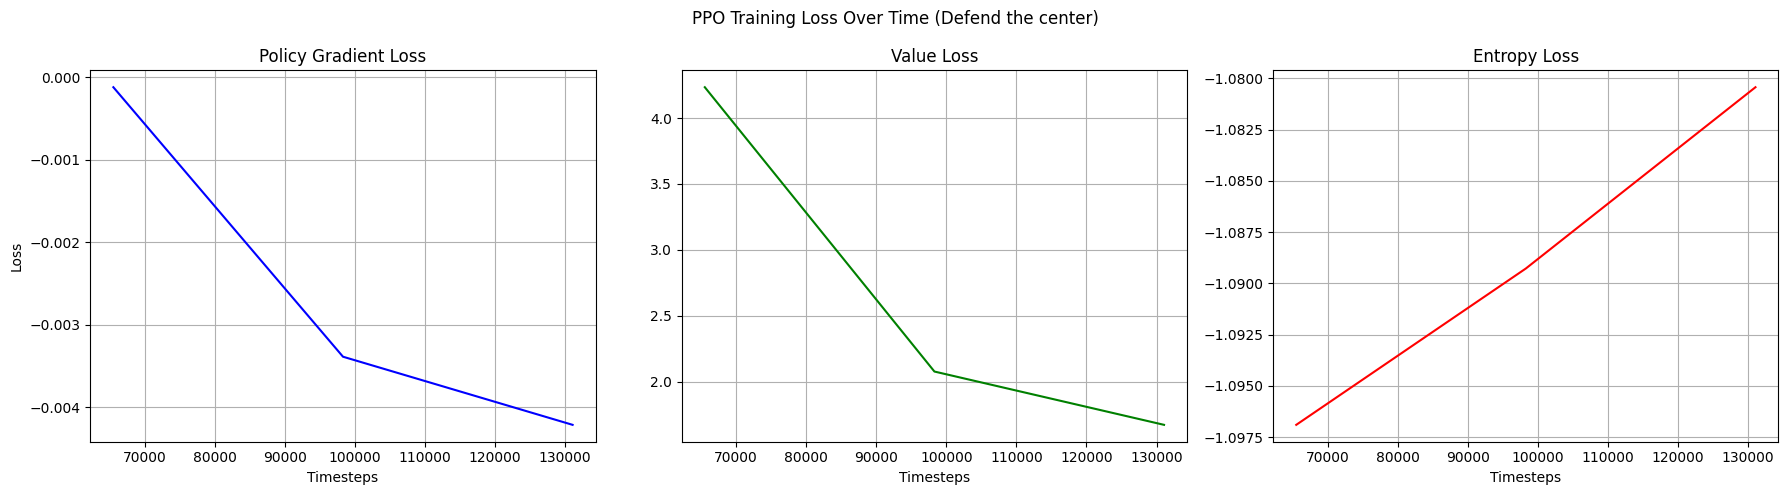

In [10]:
import os
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing import event_accumulator

# Path to your specific TensorBoard log directory
log_dir = "../logs/ppo_defend_center/ppo_defend_center_2/"
event_file = next(f for f in os.listdir(log_dir) if f.startswith("events"))
event_path = os.path.join(log_dir, event_file)

# Load the event data
ea = event_accumulator.EventAccumulator(event_path)
ea.Reload()

# print("Available scalar tags:", ea.Tags()["scalars"])

policy_loss = ea.Scalars('train/policy_gradient_loss')
value_loss = ea.Scalars('train/value_loss')
entropy_loss = ea.Scalars('train/entropy_loss')

# Convert to lists
steps = [x.step for x in policy_loss]  # assume all have same steps
policy_vals = [x.value for x in policy_loss]
value_vals = [x.value for x in value_loss]
entropy_vals = [x.value for x in entropy_loss]

# Plot in 1x3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(steps, policy_vals, color='blue')
axes[0].set_title('Policy Gradient Loss')
axes[0].set_xlabel('Timesteps')
axes[0].set_ylabel('Loss')
axes[0].grid(True)

axes[1].plot(steps, value_vals, color='green')
axes[1].set_title('Value Loss')
axes[1].set_xlabel('Timesteps')
axes[1].grid(True)

axes[2].plot(steps, entropy_vals, color='red')
axes[2].set_title('Entropy Loss')
axes[2].set_xlabel('Timesteps')
axes[2].grid(True)

fig.suptitle("PPO Training Loss Over Time (Defend the center)")

plt.tight_layout()
plt.show()

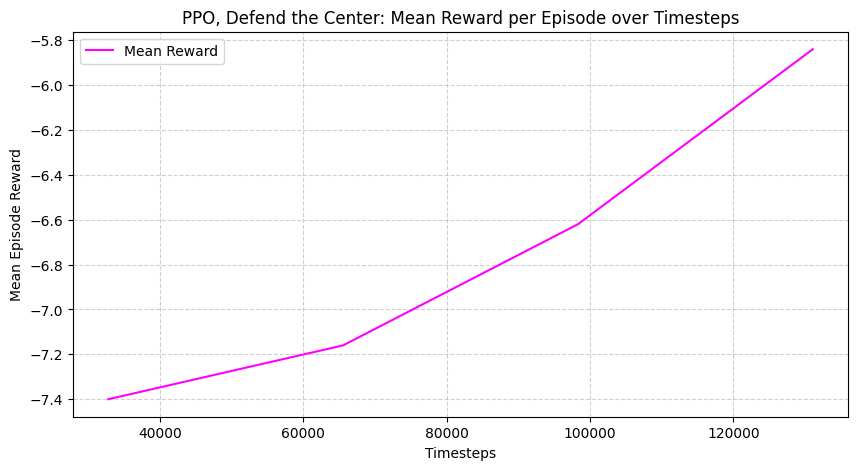

In [14]:
# Example: plot the reward mean per iteration
mean_rew = ea.Scalars("rollout/ep_rew_mean")

steps = [s.step for s in mean_rew]
values = [s.value for s in mean_rew]

plt.figure(figsize=(10, 5))
plt.plot(steps, values, label="Mean Reward", color="magenta")
plt.xlabel("Timesteps")
plt.ylabel("Mean Episode Reward")
plt.title("PPO, Defend the Center: Mean Reward per Episode over Timesteps")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

## Analysis of A2C during "Defend the Center"

Advantage Actor Critic model was trained for 125,000 timesteps with the following parameters:
      
      HParams:
         -`policy="CnnPolicy"`
         -`learning_rate=2.5e-4`
         -`n_steps=4096`
         -`batch_size=2048`
         -`gamma=0.99`
         -`gae_lambda=0.95`
         -`ent_coef=0.01`
         -`vf_coef=0.5`
         -`max_grad_norm=0.5`

The following graph shows the total rewards per episode. They seem to fluctuate a lot, however visually in the evaluation simulations, they perform equally to PPO.

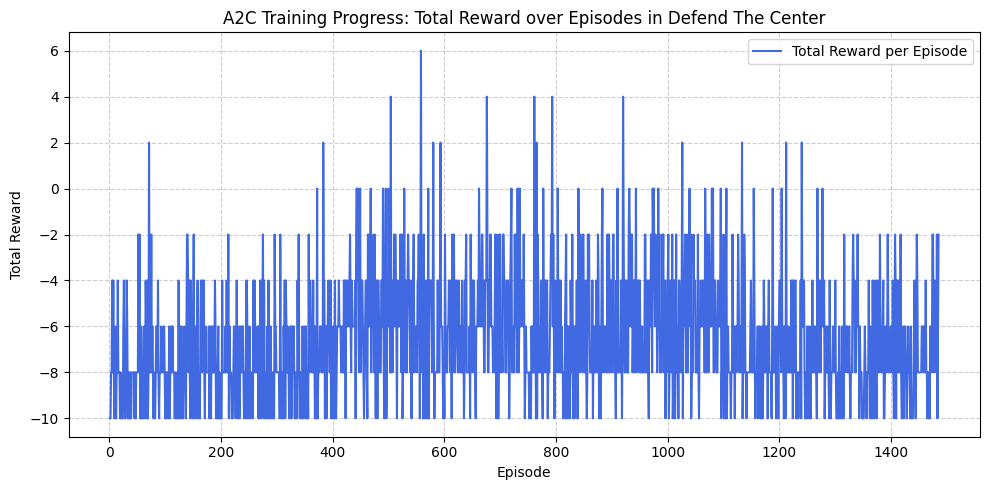

In [15]:
PPO_DEFEND_LOG_FILE = "../logs/a2c_defend_center/a2c_defend_center_episodes_v1_125000.csv"

df = pd.read_csv(PPO_DEFEND_LOG_FILE)

episode_col = "episode" if "episode" in df.columns else df.columns[0]
reward_col = "total_reward" if "total_reward" in df.columns else df.columns[-1]

# plot reward over episodes
plt.figure(figsize=(10, 5))
plt.plot(df[episode_col], df[reward_col], label="Total Reward per Episode", color='royalblue')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("A2C Training Progress: Total Reward over Episodes in Defend The Center")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
from tensorboard.backend.event_processing import event_accumulator
import os

log_dir = "../logs/ppo_deadly_corridor/ppo_deadly_corridor_125000_1/"
event_file = [f for f in os.listdir(log_dir) if f.startswith("events")][0]

ea = event_accumulator.EventAccumulator(os.path.join(log_dir, event_file))
ea.Reload()
print("Available scalar tags:", ea.Tags()["scalars"])

Available scalar tags: ['rollout/ep_len_mean', 'rollout/ep_rew_mean', 'time/fps', 'train/approx_kl', 'train/clip_fraction', 'train/clip_range', 'train/entropy_loss', 'train/explained_variance', 'train/learning_rate', 'train/loss', 'train/policy_gradient_loss', 'train/value_loss']


# Deadly Corridor performance analysis

 The reward function for both models are the same which can be also found `envs/doom_env.py`:

```
    def step(self, action):
        ...

        ...
```